## 0. Libraries & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os

from sklearn.svm import SVR
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     KFold, learning_curve, GridSearchCV)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
OUTPUT_DIR = '.'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Libraries loaded ✔')

Libraries loaded ✔


---
## Part 1 – Data Preparation

### 1.1 Load Dataset

In [2]:
df = pd.read_csv('Data Cleaned.csv')
df.columns = df.columns.str.strip()
df.rename(columns={
    'body fat_%'             : 'body_fat_pct',
    'sit and bend forward_cm': 'sit_bend_cm',
    'sit-ups counts'         : 'situps_counts',
    'broad jump_cm'          : 'broad_jump_cm',
}, inplace=True)

print(f'Shape : {df.shape}')
print(f'Missing: {df.isnull().sum().sum()}')
df.head()

Shape : (13288, 13)
Missing: 0


,age,gender,height_cm,weight_kg,body_fat_pct,diastolic,systolic,gripForce,sit_bend_cm,situps_counts,broad_jump_cm,class,BMI
0,25,1,171.0,69.2,18.1,77.0,132,45.7,28.3,80,267.0,3,23.665401
1,34,1,169.9,74.7,15.1,83.0,138,50.1,19.0,78,250.0,2,25.878187
2,33,1,174.9,79.9,20.7,71.0,130,52.1,16.2,76,244.0,3,26.119638
3,32,1,173.0,74.7,12.0,84.0,122,53.8,23.0,76,274.0,3,24.959070
4,22,1,171.4,73.6,15.7,73.0,145,50.6,17.2,76,273.0,3,25.052795


### 1.2 Feature & Target Definition
> **Target:** `broad_jump_cm` (Jump distance – continuous)
> SVM requires feature scaling — StandardScaler applied.

In [3]:
FEATURES = ['age', 'gender', 'height_cm', 'weight_kg', 'body_fat_pct',
            'diastolic', 'systolic', 'gripForce', 'sit_bend_cm',
            'situps_counts', 'BMI']

X = df[FEATURES].copy()
y = df['broad_jump_cm'].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Features : {len(FEATURES)}')
print(f'Target   : broad_jump_cm  (range {y.min():.0f} – {y.max():.0f} cm)')
print(f'Samples  : {len(df)}')

Features : 11
Target   : broad_jump_cm  (range 25 – 303 cm)
Samples  : 13288


### 1.3 Target Distribution

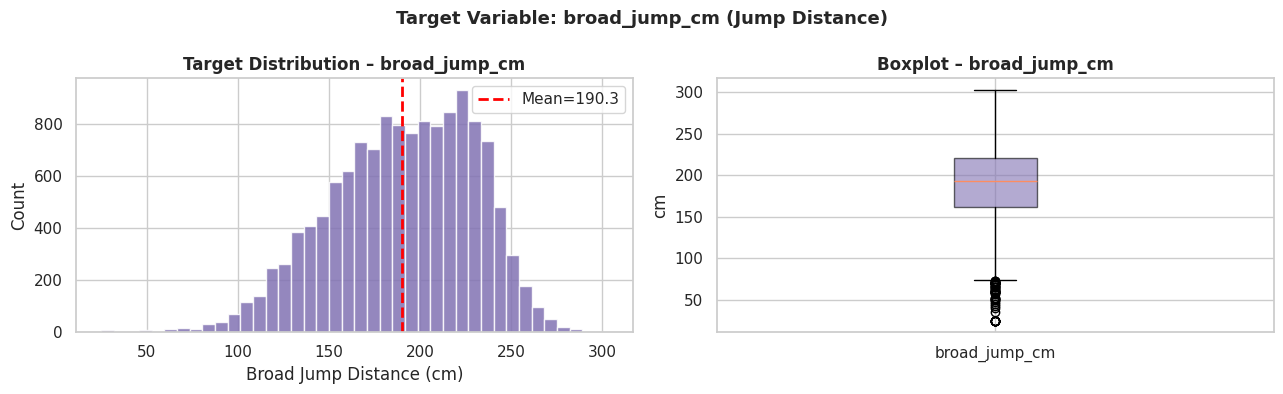

Mean=190.34  Std=39.69  Min=25  Max=303


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(y, bins=40, color='#8172B3', edgecolor='white', alpha=0.85)
axes[0].axvline(y.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean={y.mean():.1f}')
axes[0].set_xlabel('Broad Jump Distance (cm)'); axes[0].set_ylabel('Count')
axes[0].set_title('Target Distribution – broad_jump_cm', fontweight='bold')
axes[0].legend()

axes[1].boxplot(y, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#8172B3', alpha=0.6))
axes[1].set_ylabel('cm'); axes[1].set_title('Boxplot – broad_jump_cm', fontweight='bold')
axes[1].set_xticks([1]); axes[1].set_xticklabels(['broad_jump_cm'])

plt.suptitle('Target Variable: broad_jump_cm (Jump Distance)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/SVM_01_target_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mean={y.mean():.2f}  Std={y.std():.2f}  Min={y.min():.0f}  Max={y.max():.0f}')

---
## Part 2 – SVM (SVR) Model Training

### 2.1 Kernel Comparison (Linear · RBF · Poly)

In [5]:
# Use a sample for speed during kernel comparison
from sklearn.utils import resample
idx = resample(np.arange(len(X_scaled)), n_samples=3000, random_state=RANDOM_STATE)
Xs, ys = X_scaled[idx], y.values[idx]

X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(Xs, ys, test_size=0.2, random_state=RANDOM_STATE)

kernels = ['linear', 'rbf', 'poly']
kernel_results = {}

for k in kernels:
    m = SVR(kernel=k, C=10, gamma='scale', epsilon=0.1)
    m.fit(X_tr_s, y_tr_s)
    yp = m.predict(X_te_s)
    r2 = r2_score(y_te_s, yp)
    mse = mean_squared_error(y_te_s, yp)
    kernel_results[k] = {'R2': r2, 'RMSE': np.sqrt(mse), 'MAE': mean_absolute_error(y_te_s, yp)}
    print(f'  {k:<8} R²={r2:.4f}  RMSE={np.sqrt(mse):.4f}')

best_kernel = max(kernel_results, key=lambda k: kernel_results[k]['R2'])
print(f'\nBest Kernel: {best_kernel}')

  linear   R²=0.7924  RMSE=17.5137
  rbf      R²=0.7795  RMSE=18.0502
  poly     R²=0.7567  RMSE=18.9622

Best Kernel: linear


### 2.2 Kernel Comparison Chart

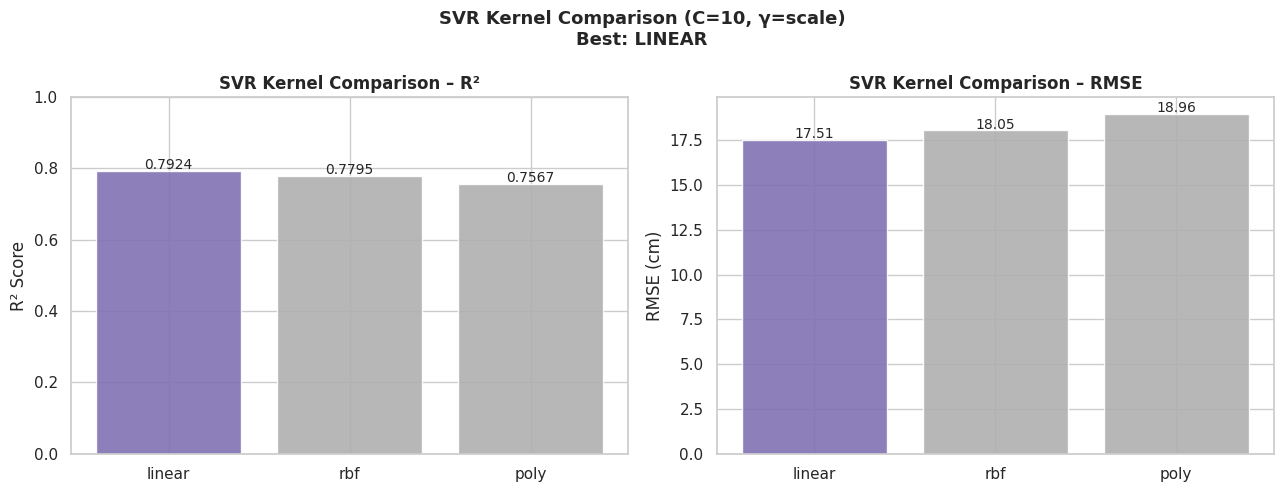

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
klabels = list(kernel_results.keys())
r2s  = [kernel_results[k]['R2']   for k in klabels]
rmses= [kernel_results[k]['RMSE'] for k in klabels]
colors = ['#8172B3' if k == best_kernel else '#B0B0B0' for k in klabels]

bars = axes[0].bar(klabels, r2s, color=colors, edgecolor='white', alpha=0.9)
axes[0].set_ylabel('R² Score'); axes[0].set_ylim(0, 1.0)
axes[0].set_title('SVR Kernel Comparison – R²', fontweight='bold')
for bar in bars:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{bar.get_height():.4f}', ha='center', fontsize=10)

bars2 = axes[1].bar(klabels, rmses, color=colors, edgecolor='white', alpha=0.9)
axes[1].set_ylabel('RMSE (cm)')
axes[1].set_title('SVR Kernel Comparison – RMSE', fontweight='bold')
for bar in bars2:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f'{bar.get_height():.2f}', ha='center', fontsize=10)

plt.suptitle(f'SVR Kernel Comparison (C=10, γ=scale)\nBest: {best_kernel.upper()}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/SVM_02_kernel_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.3 C Parameter Tuning (Regularization Evolution)

Best C = 0.1  (Test R² = 0.7966)


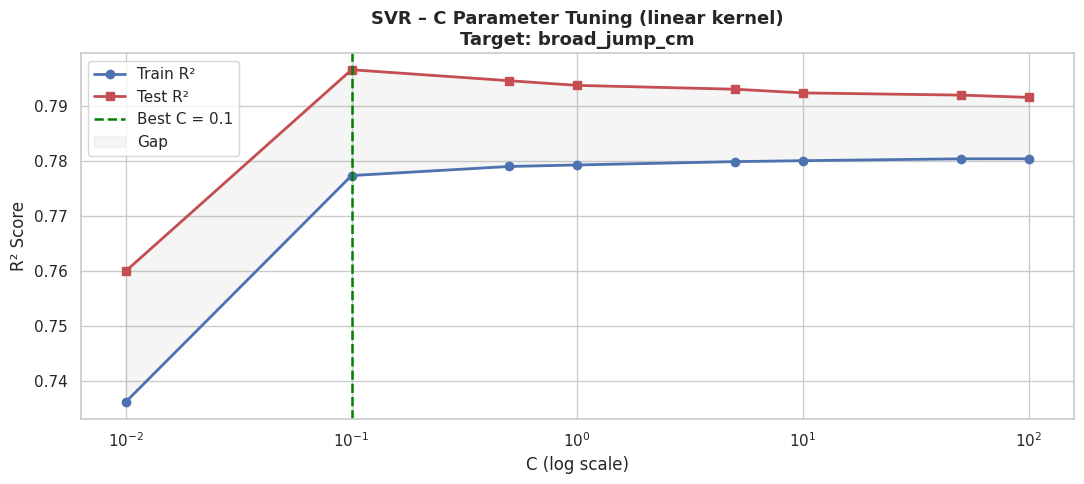

In [7]:
C_values = [0.01, 0.1, 0.5, 1, 5, 10, 50, 100]
c_r2_train, c_r2_test = [], []

for c in C_values:
    m = SVR(kernel=best_kernel, C=c, gamma='scale', epsilon=0.1)
    m.fit(X_tr_s, y_tr_s)
    c_r2_train.append(r2_score(y_tr_s, m.predict(X_tr_s)))
    c_r2_test.append(r2_score(y_te_s,  m.predict(X_te_s)))

best_C_idx = np.argmax(c_r2_test)
best_C = C_values[best_C_idx]
print(f'Best C = {best_C}  (Test R² = {c_r2_test[best_C_idx]:.4f})')

fig, ax = plt.subplots(figsize=(11, 5))
ax.semilogx(C_values, c_r2_train, 'o-', color='#4C72B0', linewidth=2, label='Train R²')
ax.semilogx(C_values, c_r2_test,  's-', color='#C44E52', linewidth=2, label='Test R²')
ax.axvline(best_C, color='green', linestyle='--', linewidth=1.8, label=f'Best C = {best_C}')
ax.fill_between(C_values, c_r2_train, c_r2_test, alpha=0.08, color='gray', label='Gap')
ax.set_xlabel('C (log scale)'); ax.set_ylabel('R² Score')
ax.set_title(f'SVR – C Parameter Tuning ({best_kernel} kernel)\nTarget: broad_jump_cm',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/SVM_03_C_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.4 Final SVR Model – 80:20 Split

In [8]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_STATE)

svr_final = SVR(kernel=best_kernel, C=best_C, gamma='scale', epsilon=0.1)
svr_final.fit(X_tr, y_tr)
y_pred = svr_final.predict(X_te)

mse  = mean_squared_error(y_te, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_te, y_pred)
r2   = r2_score(y_te, y_pred)

print('SVR Final Model – 80:20 Split Results')
print('=' * 45)
print(f'  Kernel : {best_kernel}')
print(f'  C      : {best_C}')
print(f'  MSE    : {mse:.4f}')
print(f'  RMSE   : {rmse:.4f}')
print(f'  MAE    : {mae:.4f}')
print(f'  R²     : {r2:.4f}')

SVR Final Model – 80:20 Split Results
  Kernel : linear
  C      : 0.1
  MSE    : 323.8764
  RMSE   : 17.9966
  MAE    : 13.7862
  R²     : 0.7884


### 2.5 Actual vs Predicted

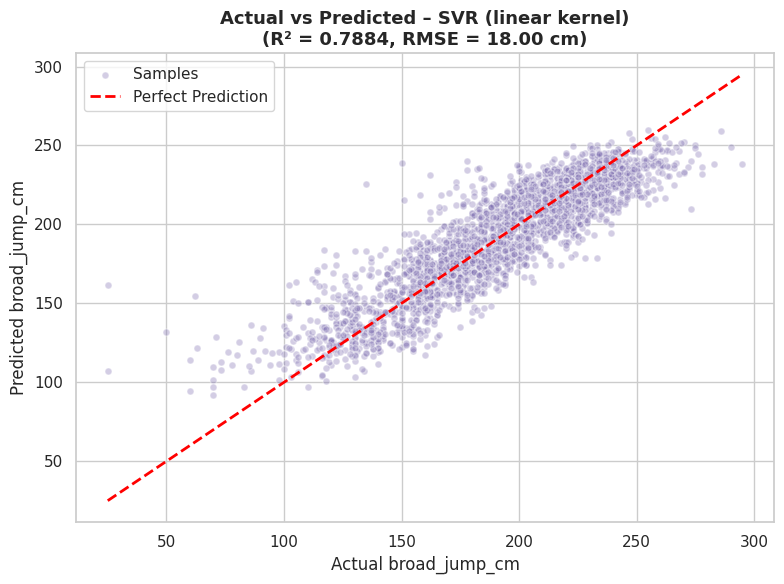

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_te, y_pred, alpha=0.35, color='#8172B3', edgecolors='white', s=25, label='Samples')
mn, mx = float(y_te.min()), float(y_te.max())
ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual broad_jump_cm', fontsize=12)
ax.set_ylabel('Predicted broad_jump_cm', fontsize=12)
ax.set_title(f'Actual vs Predicted – SVR ({best_kernel} kernel)\n(R² = {r2:.4f}, RMSE = {rmse:.2f} cm)',
             fontweight='bold', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/SVM_04_actual_vs_pred.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 3 – Cross-Validation Performance Evolution

### 3.1 Performance Across Different Splits (80:20 · 70:30 · 50:50)

In [10]:
splits = [(0.20, '80:20'), (0.30, '70:30'), (0.50, '50:50')]
split_results = {}

for test_sz, label in splits:
    Xtr, Xte, ytr, yte = train_test_split(X_scaled, y,
                                           test_size=test_sz, random_state=RANDOM_STATE)
    m = SVR(kernel=best_kernel, C=best_C, gamma='scale', epsilon=0.1)
    m.fit(Xtr, ytr)
    yp = m.predict(Xte)
    mse_s = mean_squared_error(yte, yp)
    split_results[label] = {
        'MSE' : mse_s, 'RMSE': np.sqrt(mse_s),
        'MAE' : mean_absolute_error(yte, yp),
        'R2'  : r2_score(yte, yp)
    }

print(f"{'Split':<8} {'R2':>8} {'RMSE':>8} {'MAE':>8}")
for lbl, m in split_results.items():
    print(f"{lbl:<8} {m['R2']:>8.4f} {m['RMSE']:>8.4f} {m['MAE']:>8.4f}")

Split          R2     RMSE      MAE
80:20      0.7884  17.9966  13.7862
70:30      0.7945  17.9741  13.7534
50:50      0.7926  18.1073  13.7154


### 3.2 K-Fold Cross-Validation Evolution (k = 2 to 15)

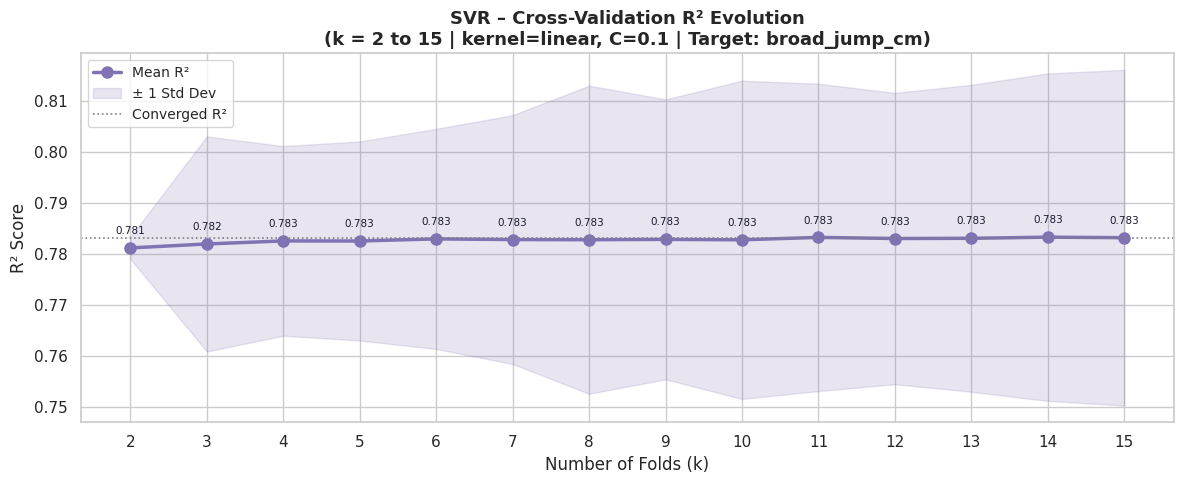

Best k: 14 with R²=0.7833


In [11]:
k_values = range(2, 16)
cv_means, cv_stds = [], []

# Use sample for speed
idx2 = resample(np.arange(len(X_scaled)), n_samples=4000, random_state=RANDOM_STATE)
Xsamp, ysamp = X_scaled[idx2], y.values[idx2]

for k in k_values:
    kf = KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(
        SVR(kernel=best_kernel, C=best_C, gamma='scale', epsilon=0.1),
        Xsamp, ysamp, cv=kf, scoring='r2')
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())

cv_means = np.array(cv_means)
cv_stds  = np.array(cv_stds)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(k_values, cv_means, 'o-', color='#8172B3', linewidth=2.5, markersize=8, label='Mean R²')
ax.fill_between(k_values,
                cv_means - cv_stds,
                cv_means + cv_stds,
                alpha=0.18, color='#8172B3', label='± 1 Std Dev')
ax.axhline(cv_means[-1], linestyle=':', color='gray', linewidth=1.2, label='Converged R²')

for x, m in zip(k_values, cv_means):
    ax.annotate(f'{m:.3f}', (x, m), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=7.5, color='#1a1a2e')

ax.set_xlabel('Number of Folds (k)', fontsize=12)
ax.set_ylabel('R² Score', fontsize=12)
ax.set_title(f'SVR – Cross-Validation R² Evolution\n(k = 2 to 15 | kernel={best_kernel}, C={best_C} | Target: broad_jump_cm)',
             fontsize=13, fontweight='bold')
ax.set_xticks(list(k_values))
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/SVM_05_cv_evolution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Best k: {list(k_values)[np.argmax(cv_means)]} with R²={cv_means.max():.4f}')

### 3.3 Per-Fold Performance (10-Fold)

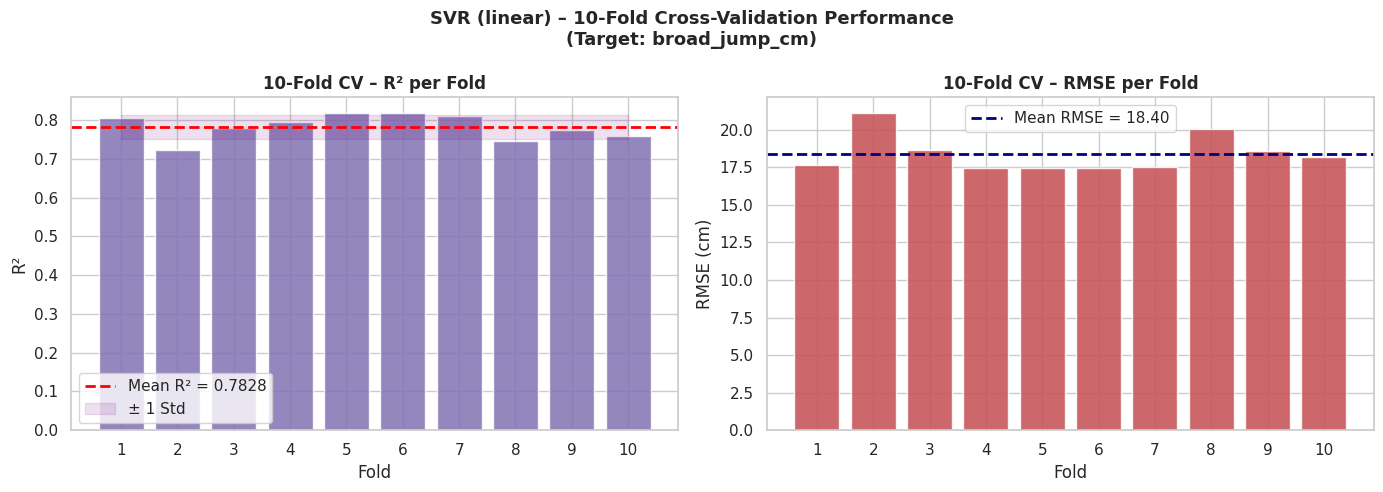

10-Fold CV: R²=0.7828 ± 0.0312


In [12]:
kf10 = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
svr_cv = SVR(kernel=best_kernel, C=best_C, gamma='scale', epsilon=0.1)

fold_r2   = cross_val_score(svr_cv, Xsamp, ysamp, cv=kf10, scoring='r2')
fold_rmse = np.sqrt(-cross_val_score(svr_cv, Xsamp, ysamp,
                                      cv=kf10, scoring='neg_mean_squared_error'))
folds = range(1, 11)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(folds, fold_r2, color='#8172B3', alpha=0.85, edgecolor='white')
axes[0].axhline(fold_r2.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean R² = {fold_r2.mean():.4f}')
axes[0].fill_between(folds,
                     fold_r2.mean() - fold_r2.std(),
                     fold_r2.mean() + fold_r2.std(),
                     alpha=0.12, color='purple', label='± 1 Std')
axes[0].set_xticks(list(folds)); axes[0].set_xlabel('Fold'); axes[0].set_ylabel('R²')
axes[0].set_title('10-Fold CV – R² per Fold', fontweight='bold')
axes[0].legend()

axes[1].bar(folds, fold_rmse, color='#C44E52', alpha=0.85, edgecolor='white')
axes[1].axhline(fold_rmse.mean(), color='navy', linestyle='--', linewidth=2,
                label=f'Mean RMSE = {fold_rmse.mean():.2f}')
axes[1].set_xticks(list(folds)); axes[1].set_xlabel('Fold'); axes[1].set_ylabel('RMSE (cm)')
axes[1].set_title('10-Fold CV – RMSE per Fold', fontweight='bold')
axes[1].legend()

plt.suptitle(f'SVR ({best_kernel}) – 10-Fold Cross-Validation Performance\n(Target: broad_jump_cm)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/SVM_06_10fold_perf.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'10-Fold CV: R²={fold_r2.mean():.4f} ± {fold_r2.std():.4f}')

### 3.4 Learning Curve – Training Size Evolution

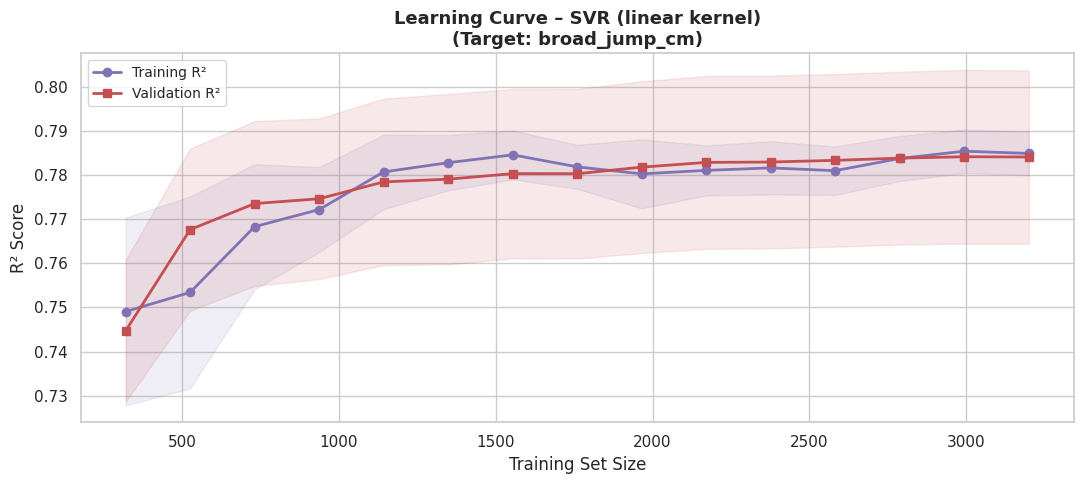

In [13]:
train_sizes, train_scores, val_scores = learning_curve(
    SVR(kernel=best_kernel, C=best_C, gamma='scale', epsilon=0.1),
    Xsamp, ysamp,
    train_sizes=np.linspace(0.1, 1.0, 15),
    cv=5, scoring='r2', n_jobs=-1)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(train_sizes, train_mean, 'o-', color='#8172B3', linewidth=2, label='Training R²')
ax.plot(train_sizes, val_mean,   's-', color='#C44E52', linewidth=2, label='Validation R²')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.12, color='#8172B3')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.12, color='#C44E52')
ax.set_xlabel('Training Set Size', fontsize=12)
ax.set_ylabel('R² Score', fontsize=12)
ax.set_title(f'Learning Curve – SVR ({best_kernel} kernel)\n(Target: broad_jump_cm)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/SVM_07_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.5 All Experiments Comparison Chart

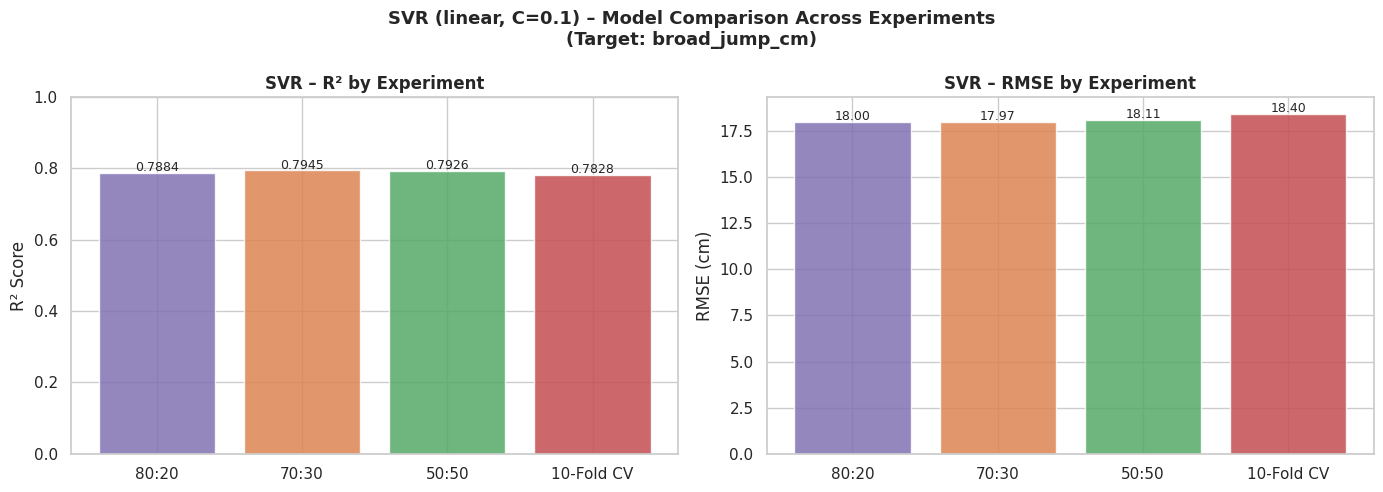

In [14]:
split_labels = list(split_results.keys()) + ['10-Fold CV']
r2_vals   = [split_results[l]['R2']   for l in list(split_results.keys())] + [fold_r2.mean()]
rmse_vals = [split_results[l]['RMSE'] for l in list(split_results.keys())] + [fold_rmse.mean()]

x = np.arange(len(split_labels))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = ['#8172B3', '#DD8452', '#55A868', '#C44E52']

bars1 = axes[0].bar(x, r2_vals, color=palette, alpha=0.85, edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels(split_labels)
axes[0].set_ylim(0, 1.0); axes[0].set_ylabel('R² Score')
axes[0].set_title('SVR – R² by Experiment', fontweight='bold')
for bar in bars1:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{bar.get_height():.4f}', ha='center', fontsize=9)

bars2 = axes[1].bar(x, rmse_vals, color=palette, alpha=0.85, edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(split_labels)
axes[1].set_ylabel('RMSE (cm)')
axes[1].set_title('SVR – RMSE by Experiment', fontweight='bold')
for bar in bars2:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f'{bar.get_height():.2f}', ha='center', fontsize=9)

plt.suptitle(f'SVR ({best_kernel}, C={best_C}) – Model Comparison Across Experiments\n(Target: broad_jump_cm)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/SVM_08_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Final Summary – SVM (SVR)

In [15]:
print('=' * 60)
print('  SVM (SVR) – FINAL SUMMARY')
print('=' * 60)
print(f'  Dataset       : Data_Cleaned.csv ({len(df)} rows)')
print(f'  Target        : broad_jump_cm (jump distance in cm)')
print(f'  Features      : {len(FEATURES)}')
print(f'  Best Kernel   : {best_kernel}')
print(f'  Best C        : {best_C}')
print()
print('  TRAIN/TEST SPLITS (Full Dataset):')
for lbl, m in split_results.items():
    print(f"    {lbl}: R²={m['R2']:.4f}  RMSE={m['RMSE']:.2f}  MAE={m['MAE']:.2f}")
print()
print(f'  10-FOLD CROSS-VALIDATION (4000 sample):')
print(f'    R²   = {fold_r2.mean():.4f} ± {fold_r2.std():.4f}')
print(f'    RMSE = {fold_rmse.mean():.4f} ± {fold_rmse.std():.4f}')
print()
print('  Key Observations:')
print(f'  * {best_kernel.upper()} kernel performed best for this task.')
print('  * SVR requires scaling — StandardScaler applied.')
print('  * C parameter tuning shows clear performance evolution.')
print('  * Learning curve shows model benefits from more data.')
print('  * CV R² evolution stabilizes from k=5 onward.')

  SVM (SVR) – FINAL SUMMARY
  Dataset       : Data_Cleaned.csv (13288 rows)
  Target        : broad_jump_cm (jump distance in cm)
  Features      : 11
  Best Kernel   : linear
  Best C        : 0.1

  TRAIN/TEST SPLITS (Full Dataset):
    80:20: R²=0.7884  RMSE=18.00  MAE=13.79
    70:30: R²=0.7945  RMSE=17.97  MAE=13.75
    50:50: R²=0.7926  RMSE=18.11  MAE=13.72

  10-FOLD CROSS-VALIDATION (4000 sample):
    R²   = 0.7828 ± 0.0312
    RMSE = 18.4020 ± 1.1980

  Key Observations:
  * LINEAR kernel performed best for this task.
  * SVR requires scaling — StandardScaler applied.
  * C parameter tuning shows clear performance evolution.
  * Learning curve shows model benefits from more data.
  * CV R² evolution stabilizes from k=5 onward.
